In [1]:

import os

os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["CUDA_VISIBLE_DEVICES"] = "2"
from pathlib import Path

root_path = Path.cwd().parent.absolute()
import sys

sys.path.append(str(root_path))
import os


In [2]:
from flax import nnx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

In [3]:
from geometry.G_matrix import G_matrix
from functionals.functions import create_potentials
from functionals.linear_funcitonal_class import LinearPotential
from functionals.internal_functional_class import InternalPotential
from functionals.interaction_functional_class import InteractionPotential
from functionals.functional import Potential
from flows.anderson_acceleration import anderson_method
from flows.gradient_flow import run_gradient_flow
from parametric_model.parametric_model import ParametricModel

In [11]:
# Define the parametric model
dim = 2
parametric_model = ParametricModel(
    parametric_map="node",  # "node" "resnet"
    rhs_model="mlp",  # "mlp" or "resnet"
    architecture=[dim, 2, 16],  # [input_dim, num_layers, hidden_width]
    activation_fn="tanh",  # "tanh", "relu", "SinTu", "identity", "sigmoid", "gelu", "swish"
    time_dependent=True,  # True or False
    solver="euler",  # "euler" or "heun"
    dt0=0.05, 
    ref_density="gaussian",
    scale_factor=1e-1,
)
_,init_params = nnx.split(parametric_model)


In [12]:
key = jax.random.PRNGKey(1234)
rngs = nnx.Rngs(key)

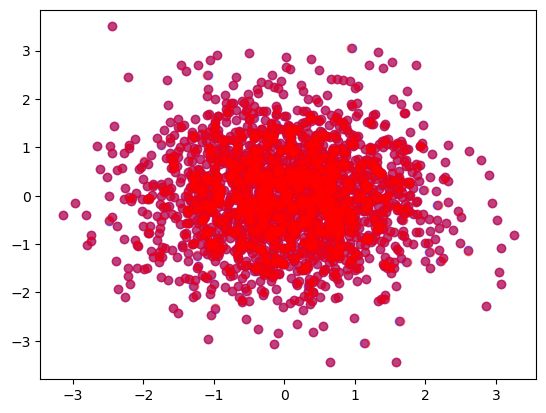

In [13]:
key,subkey = jax.random.split(key)
z_samples = jax.random.normal(subkey, (2000, dim))
y = parametric_model(samples = z_samples,params=init_params)

plt.scatter(z_samples[:,0],z_samples[:,1],c='blue',alpha=0.5)
plt.scatter(y[:,0],y[:,1],c='red',alpha=0.5)

In [14]:
G_mat_flow = G_matrix(parametric_model)
solver = "cg"  # minres or cg

In [15]:
from functionals.functions import double_well_potential_fn, styblinski_tang_potential_fn, aggregation_potential_fn,zero_potential_fn
linear_potential = LinearPotential(potential_fn= styblinski_tang_potential_fn, coeff = 1.0)
internal_potential = InternalPotential(functional='entropy', coeff = 1, method= 'exact',prob_dim=2)
interaction_potential = InteractionPotential(interaction_fn = aggregation_potential_fn, coeff = 10, a = 4, b = 2)

potential = Potential(linear = linear_potential,
                      internal = internal_potential,
                      interaction = None)

In [16]:
# Anderson parameters
h = 1e-3 # Time step size
m = 8# Number of previous iterates to consider
beta = 1.75 # Damping parameter
max_iterations = 300
tolerance = 1e-4
l2_reg_gamma = 1e-3
n_samples = 5_000  # Monte Carlo sample size

key = jax.random.PRNGKey(1234)
rngs = nnx.Rngs(key)


# Generate reference samples from λ = N(0, I)
key, subkey = jax.random.split(key)
z_samples = jax.random.normal(subkey, (n_samples, 2))

G_mat_flow = G_matrix(parametric_model)


Starting Anderson-accelerated gradient flow
  n_iterations: 300
  step_size: 0.001
  memory_size: 8
  mixing_parameter: 1.75
------------------------------------------------------------
Iter    0 | Energy: -1.616923e+01 | Residual: 2.284440e-02 | 


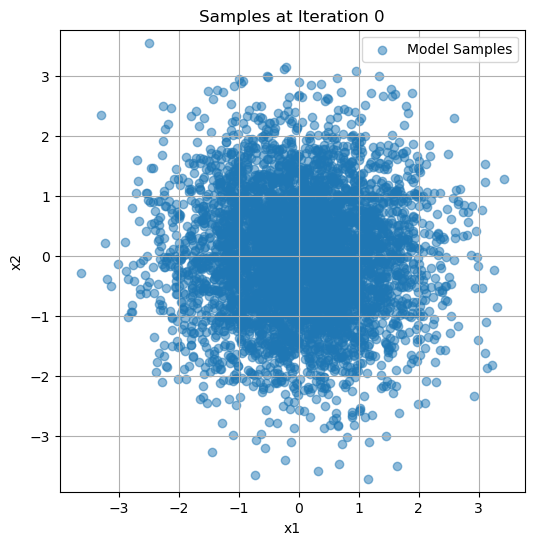

Iter    1 | Energy: -1.397274e+01 | Residual: 7.531584e-03 | 


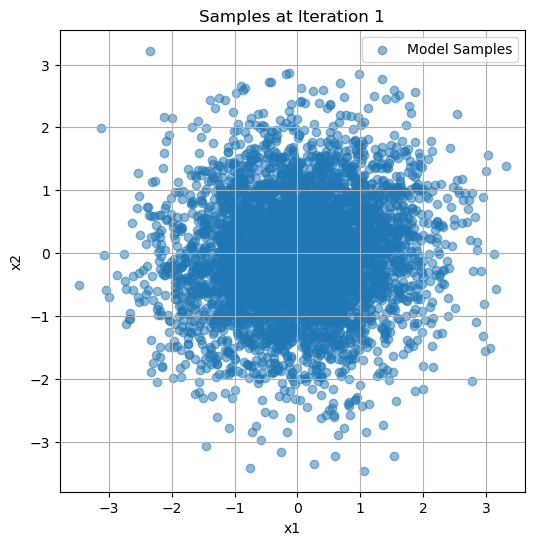

Iter    2 | Energy: -1.422209e+01 | Residual: 6.147428e-03 | 


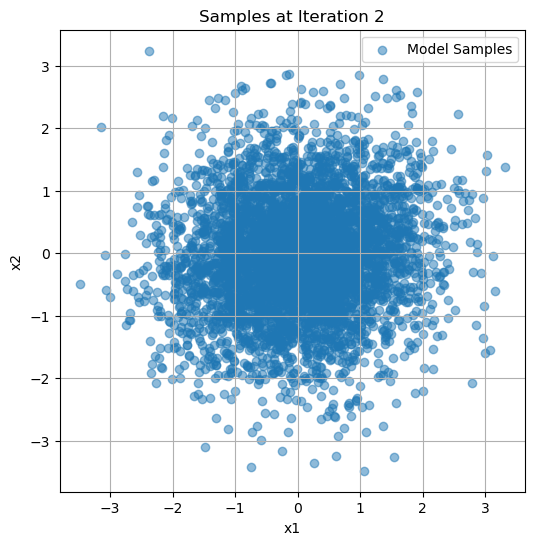

Iter    3 | Energy: -1.476905e+01 | Residual: 6.071775e-03 | 


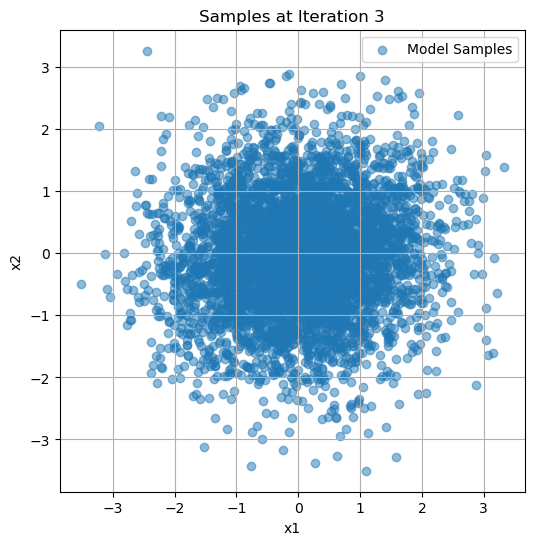

Iter    4 | Energy: -1.536910e+01 | Residual: 5.984587e-03 | 


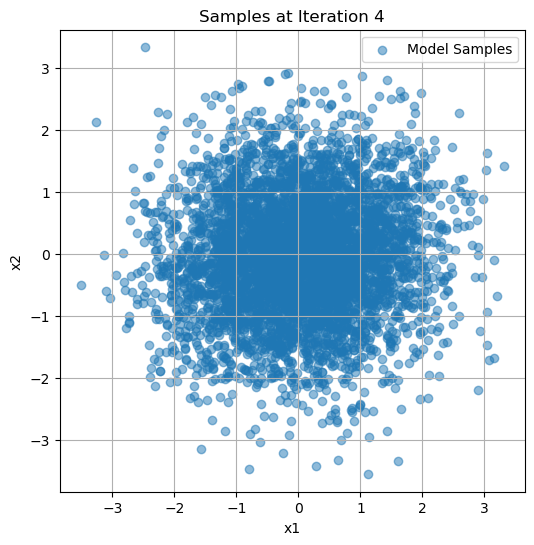

Iter   25 | Energy: -2.841261e+01 | Residual: 7.529081e-04 | 


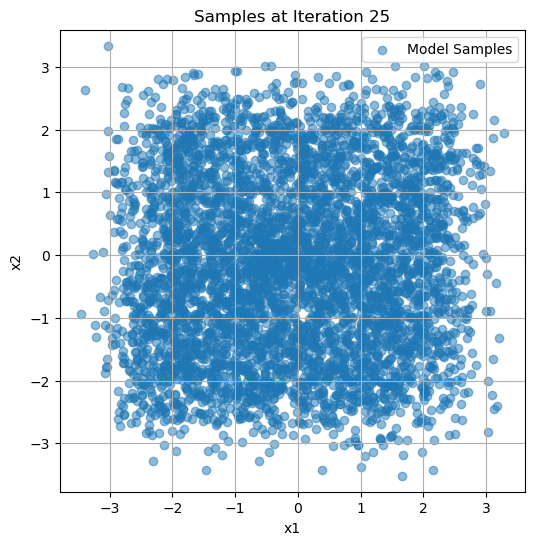

Iter   50 | Energy: -4.324245e+01 | Residual: 2.460416e-04 | 


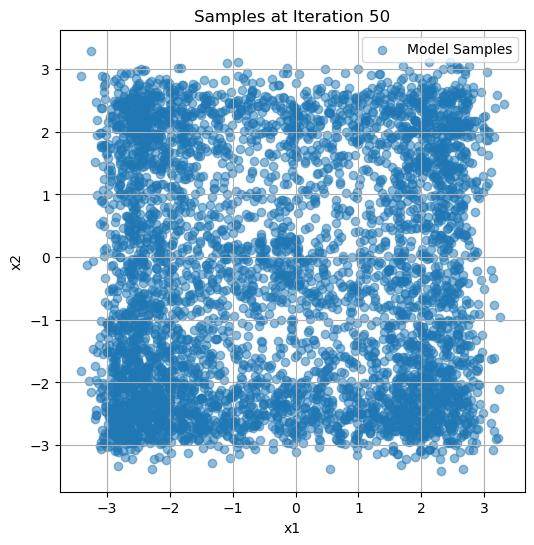

Iter   75 | Energy: -5.358947e+01 | Residual: 1.352590e-04 | 


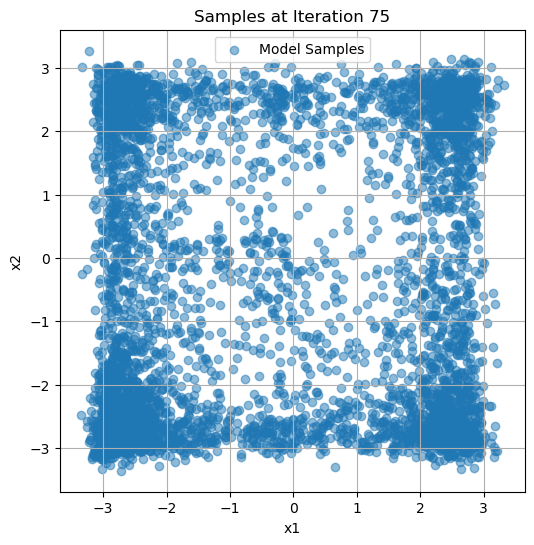

Iter  100 | Energy: -5.946141e+01 | Residual: 7.051646e-04 | 


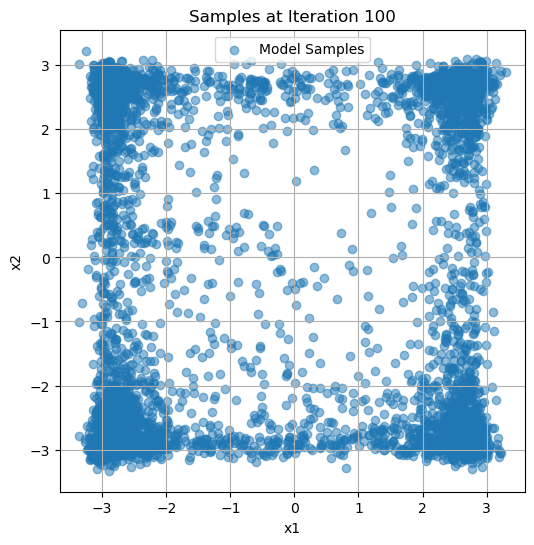

Iter  125 | Energy: -6.270972e+01 | Residual: 5.195407e-04 | 


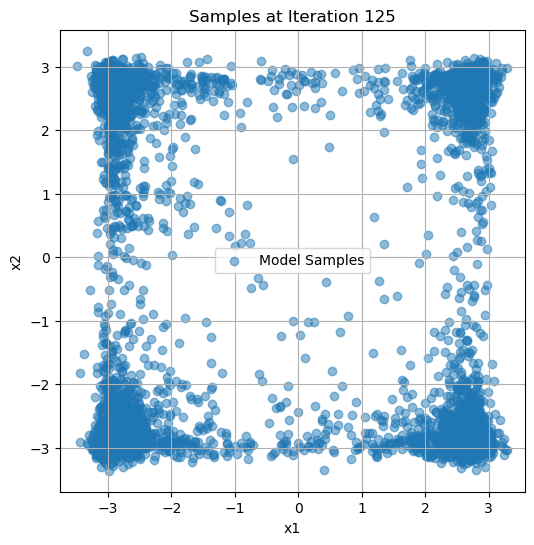

Iter  150 | Energy: -6.454734e+01 | Residual: 3.226352e-04 | 


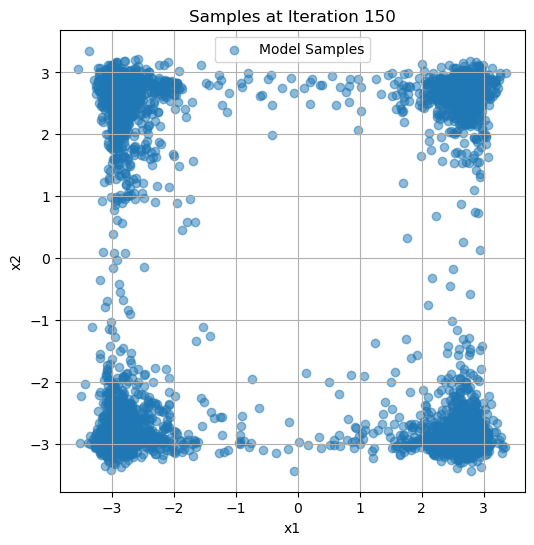

Iter  175 | Energy: -6.548258e+01 | Residual: 2.316070e-04 | 


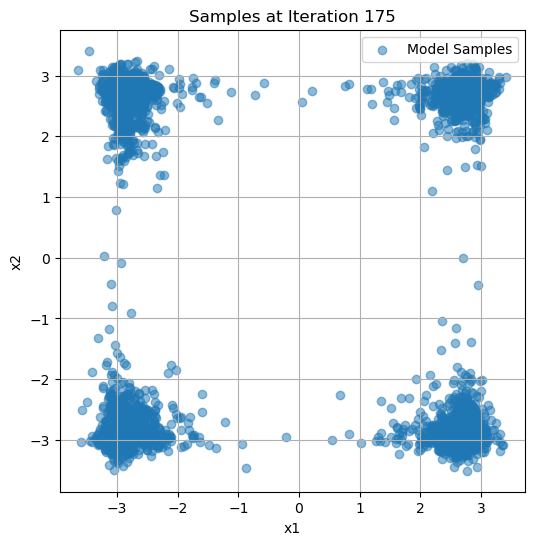

Iter  200 | Energy: -6.581002e+01 | Residual: 2.076427e-04 | 


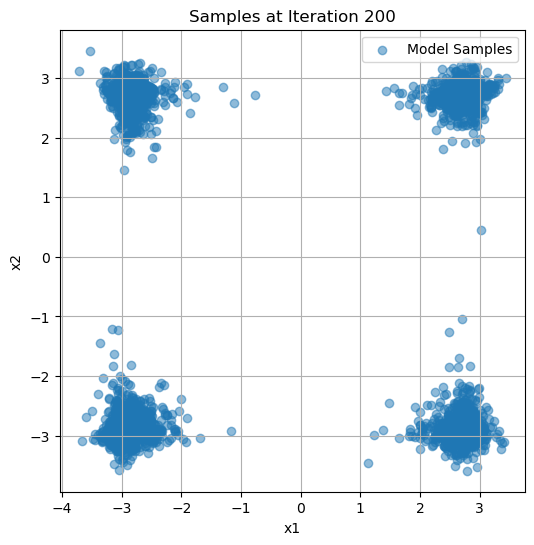

Iter  225 | Energy: -6.588484e+01 | Residual: 4.670359e-04 | 


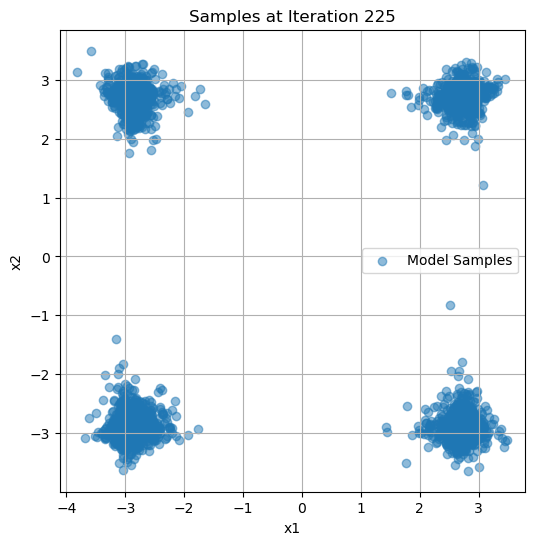

Iter  250 | Energy: -6.590565e+01 | Residual: 1.352437e-04 | 


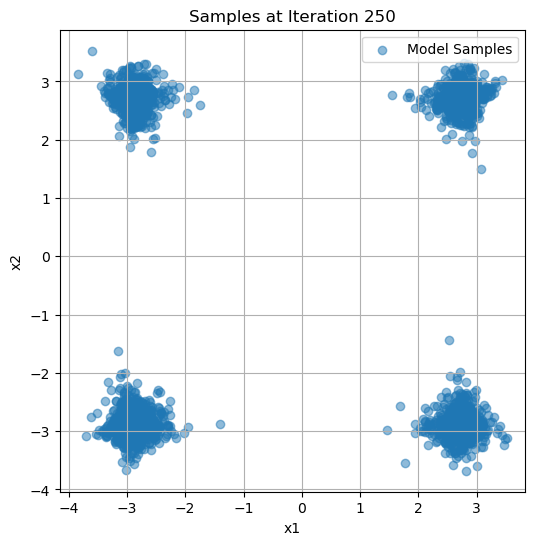

Iter  275 | Energy: -6.591051e+01 | Residual: 9.632154e-05 | 


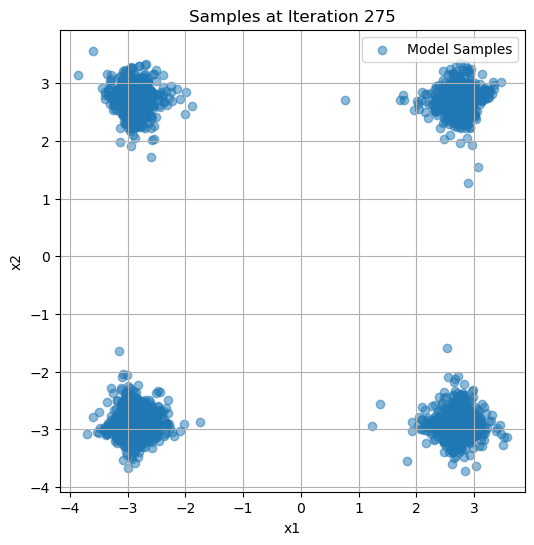

------------------------------------------------------------
Reached maximum iterations (300)
Final residual norm: 8.634700e-05
Final energy: -6.592605e+01


In [17]:
current_params, history = anderson_method(
    parametric_model, 
    n_samples, 
    z_samples, 
    G_mat_flow, 
    potential,
    solver=solver,
    initial_params=init_params,
    n_iterations=max_iterations, 
    step_size=h, 
    memory_size=m, 
    relaxation=beta, 
    l2_reg_gamma=l2_reg_gamma,
    plot_intermediate=True,
    plot_frequency=25
)

In [ ]:
samples = parametric_model(samples = z_samples,params=current_params)

In [ ]:
plt.figure(figsize=(6,6))   
plt.scatter(samples[:, 0], samples[:, 1], alpha=0.5)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Samples from Parametric Model')
plt.grid(True)
plt.show()

In [ ]:
# Define the parametric model
dim = 2
parametric_model_gf = ParametricModel(
    parametric_map="node",  # "node" "resnet"
    rhs_model="mlp",  # "mlp" or "resnet"
    architecture=[dim, 2, 64],  # [input_dim, num_layers, hidden_width]
    activation_fn="tanh",  # "tanh", "relu", "SinTu", "identity", "sigmoid", "gelu", "swish"
    time_dependent=True,  # True or False
    solver="euler",  # "euler" or "heun"
    dt0=0.05, 
    ref_density="gaussian",
    scale_factor=1e-2,
)
# _,init_params = nnx.split(parametric_model)


In [ ]:


# Gradient flow parameters
h = 1e-3 # Time step size2
# max_iterations = 500
# tolerance = 1e-6
# n_samples = 10_000  # Monte Carlo sample size


key = jax.random.PRNGKey(1234)
rngs = nnx.Rngs(key)


# Generate reference samples from λ = N(0, I)
key, subkey = jax.random.split(key)
z_samples = jax.random.normal(subkey, (n_samples, 2))

G_mat_flow = G_matrix(parametric_model_gf)

solver= 'cg'



In [ ]:


results = run_gradient_flow(
    parametric_model_gf, z_samples, G_mat_flow,
    potential
    ,solver=solver,
    h=h, max_iterations=max_iterations, tolerance=tolerance,
    progress_every=10,regularization=1e-4
)



In [ ]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(20,10))
ax = axs[0]
e_gd = results["energy_history"]
e_gd = jnp.array(e_gd)
e_am = history["energies"]
e_am = jnp.array(e_am)
e_min = jnp.min(jnp.concatenate((e_gd, e_am))) - 1e-10
e_gd -= e_min  # so that we can safely plot in log scale
e_am -= e_min
ax.plot(e_gd, label='GD', linewidth=4)
ax.plot(e_am, label='Anderson', linewidth=4)
ax.tick_params(axis='both', which='major', labelsize=24)
ax.set_yscale("log")
ax.set_xlabel('Iteration',fontsize=32)
ax.set_ylabel('Energy Error',fontsize=32)
# ax.set_ylim(1e-2, None)
ax.grid()
ax.set_title(r'$\mathcal{E} - \mathcal{E}_{\text{min}}$', fontsize=32)

ax = axs[1]

ax.plot(results['riemann_grad_norm_history'], label='GD',linewidth=4)
ax.plot(history['riemann_grad_history'], label='Anderson', linewidth=4)
ax.set_yscale('log')
ax.tick_params(axis='both', which='major', labelsize=24)
ax.grid()
ax.set_title(r"$\| \nabla_\theta F\|_{G(\theta)}$", fontsize=32)
ax.set_xlabel('Iteration',fontsize=32)
ax.set_ylabel(r'$\| \nabla_\theta F\|_{G(\theta)}$', fontsize=32)

# ax = axs[2]
# ax.plot(history['euclid_grad_norm_history'], label='GD')
# ax.set_yscale('log')
# ax.grid()
# ax.set_title(r"$\| \nabla_\theta F\|_2$")

axs[-1].legend(fontsize=24)

fig.tight_layout()
fig.savefig('GD_vs_AM.pdf')